# Subsitution based on ancestral sequence

In [1]:
#!/usr/bin/env python3
"""
Per-position substitution counts and ancestral nucleotide content, derived from
the Ensembl EPO ancestral-allele FASTAs (Homo-Pan ancestor node).

Produces two TSVs per lineage, in exactly the format consumed by
Equilibrium.ipynb section 1a:

  <prefix>_mutation_count.txt
      Position  A>G  T>C  C>G  T>G  C>A  A>T  G>C  G>T  C>T  T>A  A>C  G>A
      (C>T and G>A are non-CpG only, CpG status defined on the ANCESTRAL seq)

  <prefix>_ancestral_content.txt
      Position  A  T  C  G  C (non-CpG)  G (non-CpG)

Human lineage : ancestor FASTA in GRCh38 coords vs GRCh38 reference.
Chimp lineage : ancestor FASTA in Pan_tro_3.0 coords vs Pan_tro_3.0 reference.

Both ancestor FASTAs describe the SAME node (the human-chimp common ancestor),
projected onto each genome. Uppercase = high-confidence call, which for each
file means the call is supported by BOTH the sister species and the
human-chimp-gorilla ancestor. Running each lineage against its own file keeps
the confidence filter symmetric between the two lineages.

Usage:
    python ancestral_substitution_counts.py human
    python ancestral_substitution_counts.py chimp
    python ancestral_substitution_counts.py both
"""

import sys
import os
import numpy as np
import pandas as pd
import pyfaidx

# =============================================================================
# CONFIG
# =============================================================================
CONFIG = {
    'human': {
        'bed':        '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Human_Protein_Coding_Genes_GTF_Best_TSS_5kb_Seq.gff',
        'ref_fasta':  '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homo_sapiens.GRCh38.dna.toplevel.fa',
        'anc_dir':    '/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/alleleFreq_tss/ancestor/homo_sapiens_ancestor_GRCh38',
        'anc_prefix': 'homo_sapiens_ancestor_',
        'out_prefix': 'human_lineage_EPO',
    },
    'chimp': {
        'bed':        '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Chimpanzee_Protein_Coding_Genes_GTF_Best_TSS_10kb_Seq.gff',
        'ref_fasta':  '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Pan_troglodytes.Pan_tro_3.0.dna.toplevel.fa',
        'anc_dir':    '/media/alexpalazzo1/ohta/Tina/TSS_hypermutation/Rare_SNP/alleleFreq_tss/ancestor/pan_troglodytes_ancestor_Pan_tro_3.0',
        'anc_prefix': 'pan_troglodytes_ancestor_',
        'out_prefix': 'chimp_lineage_EPO',
    },
}

WINDOW = 5000              # bp centred on the TSS (2500 up / 2500 down)
HIGH_CONFIDENCE_ONLY = True   # keep only uppercase ancestral calls
MASK_SOFTMASKED_REF = False   # True -> drop repeat-masked (lowercase) reference bases

MUT_COLS = ['A>G', 'T>C', 'C>G', 'T>G', 'C>A', 'A>T',
            'G>C', 'G>T', 'C>T', 'T>A', 'A>C', 'G>A']

# =============================================================================
# byte-level helpers  (uint8 ASCII codes)
# =============================================================================
A, C, G, T = 65, 67, 71, 84
BASES = np.array([A, C, G, T], dtype=np.uint8)

_COMP = np.arange(256, dtype=np.uint8)
for a, b in [(65, 84), (84, 65), (67, 71), (71, 67),
             (97, 116), (116, 97), (99, 103), (103, 99)]:
    _COMP[a] = b
# non-ACGT (N, '.', '-') complement to themselves


def _to_u8(s):
    return np.frombuffer(s.encode('ascii', 'replace'), dtype=np.uint8)


def _revcomp_u8(arr):
    return _COMP[arr][::-1]


def _upper(arr):
    """ASCII uppercase for letters; leaves '.', '-' untouched."""
    return np.where((arr >= 97) & (arr <= 122), arr - 32, arr)


# =============================================================================
# FASTA access
# =============================================================================
class AncestorFasta:
    """One record per chromosome file: homo_sapiens_ancestor_<chrom>.fa"""

    def __init__(self, directory, prefix):
        self.dir, self.prefix, self._cache = directory, prefix, {}

    def get(self, chrom):
        c = chrom[3:] if chrom.startswith('chr') else chrom
        if c == 'M':
            c = 'MT'
        if c not in self._cache:
            path = os.path.join(self.dir, f'{self.prefix}{c}.fa')
            if os.path.exists(path):
                fa = pyfaidx.Fasta(path, sequence_always_upper=False)
                self._cache[c] = fa[list(fa.keys())[0]]
            else:
                self._cache[c] = None
        return self._cache[c]


class RefFasta:
    def __init__(self, path):
        self.fa = pyfaidx.Fasta(path, sequence_always_upper=False)
        self.keys = set(self.fa.keys())

    def get(self, chrom):
        for cand in (chrom, chrom.lstrip('chr'), 'chr' + chrom):
            if cand in self.keys:
                return self.fa[cand]
        return None


# =============================================================================
# main counter
# =============================================================================
def build(species, config=CONFIG, window=WINDOW, verbose_every=2000):
    cfg = config[species]

    bed = pd.read_csv(cfg['bed'], sep='\t', header=None,
                      names=['chrom', 'start', 'end', 'gene', 'score', 'strand'],
                      dtype={'chrom': str})
    print(f"[{species}] {len(bed):,} windows from {cfg['bed']}")

    anc_src = AncestorFasta(cfg['anc_dir'], cfg['anc_prefix'])
    ref_src = RefFasta(cfg['ref_fasta'])

    half = window // 2
    # accumulators, indexed 0..window-1 along the gene-oriented window
    content = {k: np.zeros(window, dtype=np.int64)
               for k in ['A', 'T', 'C', 'G', 'C (non-CpG)', 'G (non-CpG)']}
    muts = {k: np.zeros(window, dtype=np.int64) for k in MUT_COLS}

    stats = dict(used=0, no_anc_chrom=0, no_ref_chrom=0, short=0, oob=0)

    for i, row in enumerate(bed.itertuples(index=False)):
        if verbose_every and i and i % verbose_every == 0:
            print(f"  {i:,}/{len(bed):,}  (used {stats['used']:,})")

        arec = anc_src.get(row.chrom)
        if arec is None:
            stats['no_anc_chrom'] += 1
            continue
        rrec = ref_src.get(row.chrom)
        if rrec is None:
            stats['no_ref_chrom'] += 1
            continue

        centre = int(row.start) + (int(row.end) - int(row.start)) // 2
        lo, hi = centre - half - 1, centre + half + 1   # 0-based, +1bp flank each side
        if lo < 0 or hi > len(arec) or hi > len(rrec):
            stats['oob'] += 1
            continue

        anc = _to_u8(str(arec[lo:hi]))
        ref = _to_u8(str(rrec[lo:hi]))
        if anc.size != window + 2 or ref.size != window + 2:
            stats['short'] += 1
            continue

        if row.strand == '-':
            anc, ref = _revcomp_u8(anc), _revcomp_u8(ref)

        anc_u = _upper(anc)
        ref_u = _upper(ref)

        a_core, a_up, a_dn = anc_u[1:-1], anc_u[:-2], anc_u[2:]
        r_core = ref_u[1:-1]

        # --- validity mask -------------------------------------------------
        ok = np.isin(a_core, BASES) & np.isin(r_core, BASES)
        if HIGH_CONFIDENCE_ONLY:
            ok &= (anc[1:-1] < 97)          # uppercase in the raw ancestral seq
        if MASK_SOFTMASKED_REF:
            ok &= (ref[1:-1] < 97)
        if not ok.any():
            continue

        # --- ancestral CpG context (defined on the ancestral sequence) ------
        anc_cpg = ((a_core == C) & (a_dn == G)) | ((a_core == G) & (a_up == C))

        # --- content --------------------------------------------------------
        for base, name in [(A, 'A'), (T, 'T'), (C, 'C'), (G, 'G')]:
            content[name] += ok & (a_core == base)
        content['C (non-CpG)'] += ok & (a_core == C) & ~anc_cpg
        content['G (non-CpG)'] += ok & (a_core == G) & ~anc_cpg

        # --- substitutions ---------------------------------------------------
        diff = ok & (a_core != r_core)
        if diff.any():
            for anc_b, anc_n in [(A, 'A'), (C, 'C'), (G, 'G'), (T, 'T')]:
                sel_a = diff & (a_core == anc_b)
                if not sel_a.any():
                    continue
                for der_b, der_n in [(A, 'A'), (C, 'C'), (G, 'G'), (T, 'T')]:
                    if der_b == anc_b:
                        continue
                    key = f'{anc_n}>{der_n}'
                    sel = sel_a & (r_core == der_b)
                    if key in ('C>T', 'G>A'):
                        sel = sel & ~anc_cpg        # non-CpG only
                    muts[key] += sel

        stats['used'] += 1

    print(f"[{species}] windows used: {stats['used']:,}   "
          f"skipped: anc-chrom {stats['no_anc_chrom']}, ref-chrom {stats['no_ref_chrom']}, "
          f"oob {stats['oob']}, short {stats['short']}")

    pos = np.arange(1, window + 1)
    mut_df = pd.DataFrame({'Position': pos, **{k: muts[k] for k in MUT_COLS}})
    con_df = pd.DataFrame({'Position': pos,
                           **{k: content[k] for k in
                              ['A', 'T', 'C', 'G', 'C (non-CpG)', 'G (non-CpG)']}})

    mut_out = f"{cfg['out_prefix']}_mutation_count.txt"
    con_out = f"{cfg['out_prefix']}_ancestral_content.txt"
    mut_df.to_csv(mut_out, sep='\t', index=False)
    con_df.to_csv(con_out, sep='\t', index=False)
    print(f"[{species}] wrote {mut_out}\n[{species}] wrote {con_out}")

    tot_sub = mut_df[MUT_COLS].values.sum()
    tot_sites = con_df[['A', 'T', 'C', 'G']].values.sum()
    print(f"[{species}] {tot_sub:,} substitutions over {tot_sites:,} callable sites "
          f"(divergence {tot_sub / tot_sites:.5f})")
    return mut_df, con_df


if __name__ == '__main__':
    which = sys.argv[1] if len(sys.argv) > 1 else 'both'
    for sp in (['human', 'chimp'] if which == 'both' else [which]):
        build(sp)

KeyError: '-f'

     parsimony    EPO  ratio_EPO/pars  frac_of_total_pars  frac_of_total_EPO
A>G      31741  74047          2.3329              0.1529             0.1613
T>C      31815  70447          2.2143              0.1533             0.1535
C>G      13164  29126          2.2125              0.0634             0.0634
T>G       8619  20142          2.3369              0.0415             0.0439
C>A      11150  24101          2.1615              0.0537             0.0525
A>T       6458  15610          2.4172              0.0311             0.0340
G>C      13120  28414          2.1657              0.0632             0.0619
G>T      11629  25994          2.2353              0.0560             0.0566
C>T      33476  69094          2.0640              0.1613             0.1505
T>A       6188  15195          2.4556              0.0298             0.0331
A>C       8571  19538          2.2795              0.0413             0.0426
G>A      31614  67352          2.1304              0.1523             0.1467

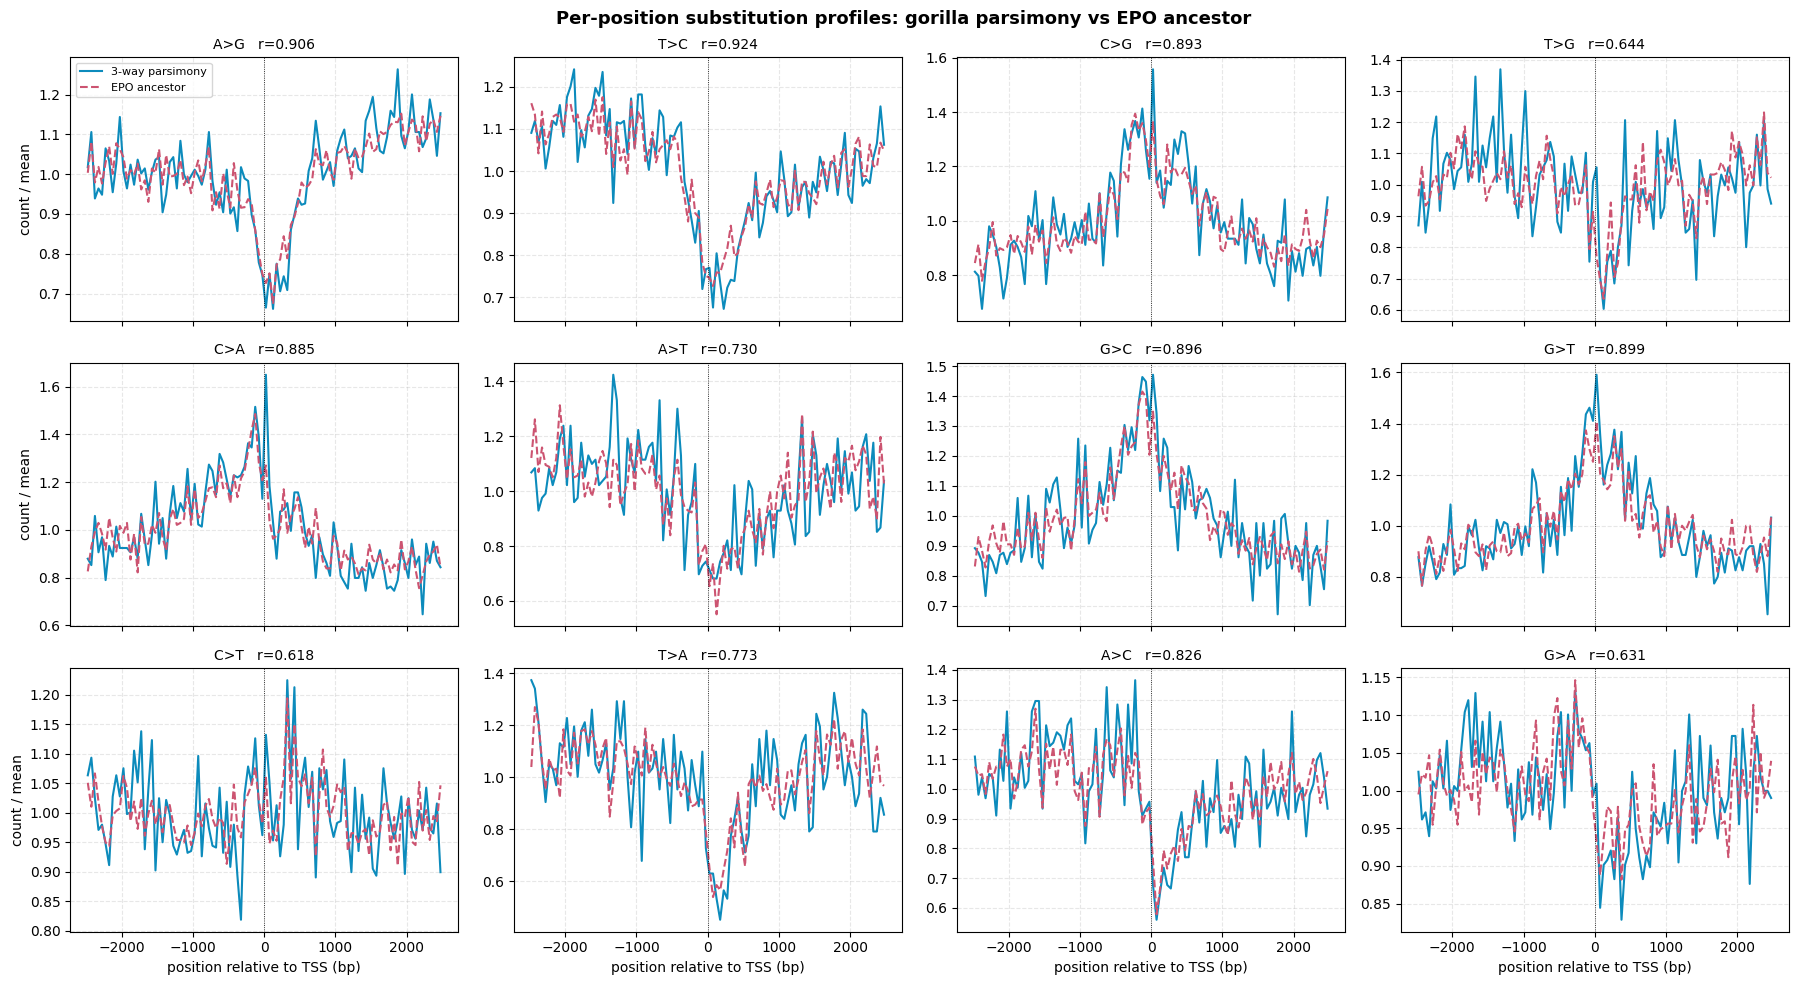

In [2]:
#!/usr/bin/env python3
"""
Compare the EPO-ancestor substitution counts against the original 3-way
(gorilla-outgroup parsimony) counts, per position and per mutation type.

If the two methods give the same
per-position rate profile across the TSS window, ancestral misassignment is
not driving the equilibrium result.

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PARSIMONY = '/media/alexpalazzo1/ohta/Tina/SNPs_and_Indels/PrimateSNPs/Homologous Primate Genes All Alignment 60.0% Cutoff Primate SNP Human_mutation_count.txt'
EPO       = 'human_lineage_EPO_mutation_count.txt'
BIN       = 50

MUT_COLS = ['A>G', 'T>C', 'C>G', 'T>G', 'C>A', 'A>T',
            'G>C', 'G>T', 'C>T', 'T>A', 'A>C', 'G>A']

p = pd.read_csv(PARSIMONY, sep='\t')
e = pd.read_csv(EPO, sep='\t')
n = min(len(p), len(e))
p, e = p.iloc[:n].copy(), e.iloc[:n].copy()

for d in (p, e):
    d['Bin'] = (d['Position'] - 1) // BIN + 1
pb = p.groupby('Bin')[MUT_COLS].sum()
eb = e.groupby('Bin')[MUT_COLS].sum()
x = (pb.index - 0.5) * BIN - n // 2      # TSS-relative bp

# ---- totals table ----------------------------------------------------------
tot = pd.DataFrame({'parsimony': p[MUT_COLS].sum(), 'EPO': e[MUT_COLS].sum()})
tot['ratio_EPO/pars'] = tot['EPO'] / tot['parsimony']
tot['frac_of_total_pars'] = tot['parsimony'] / tot['parsimony'].sum()
tot['frac_of_total_EPO'] = tot['EPO'] / tot['EPO'].sum()
print(tot.to_string(float_format=lambda v: f'{v:.4f}'))

r = np.corrcoef(tot['parsimony'], tot['EPO'])[0, 1]
print(f"\nPearson r across the 12 mutation types (totals): {r:.4f}")

# ---- per-position profiles, each type normalised to its own mean ------------
fig, axes = plt.subplots(3, 4, figsize=(18, 10), sharex=True)
for ax, m in zip(axes.ravel(), MUT_COLS):
    ax.plot(x, pb[m] / pb[m].mean(), color='#0C8BBC', lw=1.5, label='3-way parsimony')
    ax.plot(x, eb[m] / eb[m].mean(), color='#CC5471', lw=1.5, ls='--', label='EPO ancestor')
    rr = np.corrcoef(pb[m], eb[m])[0, 1]
    ax.set_title(f'{m}   r={rr:.3f}', fontsize=10)
    ax.axvline(0, color='k', lw=0.6, ls=':')
    ax.grid(alpha=0.3, ls='--')
axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel('position relative to TSS (bp)')
for ax in axes[:, 0]:
    ax.set_ylabel('count / mean')
fig.suptitle('Per-position substitution profiles: gorilla parsimony vs EPO ancestor',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('EPO_vs_parsimony_profiles.pdf', bbox_inches='tight', dpi=300)
plt.savefig('EPO_vs_parsimony_profiles.png', bbox_inches='tight', dpi=150)
print('\nSaved EPO_vs_parsimony_profiles.pdf / .png')

In [4]:
import pandas as pd

content_file = "human_lineage_EPO_ancestral_content.txt"
content_df = pd.read_csv(content_file, sep='\t')

# Bin numbers: 50 positions per bin -> 100 bins for a 5000-bp window
content_df['Bin'] = ((content_df['Position'] - 1) // 50) + 1

# Sum total (CpG-inclusive) A, T, C, G content within each bin
# (A and T are needed as the denominator, same as the Actual_%'s in the
# equilibrium notebook: content / (A+T+C+G) * 100)
binned_df = content_df.groupby('Bin').agg({
    'A': 'sum', 'T': 'sum', 'C': 'sum', 'G': 'sum'
}).reset_index()
binned_df.rename(columns={'Bin': 'Position'}, inplace=True)

total = binned_df['A'] + binned_df['T'] + binned_df['C'] + binned_df['G']
binned_df['Actual_C%'] = 100 * binned_df['C'] / total
binned_df['Actual_G%'] = 100 * binned_df['G'] / total

output_file = "human_lineage_EPO_CpG_inclusive_CG_binned.csv"
binned_df[['Position', 'Actual_C%', 'Actual_G%']].to_csv(output_file, index=False)
print(f"Wrote {output_file}")
print(binned_df[['Position', 'Actual_C%', 'Actual_G%']].head())

Wrote human_lineage_EPO_CpG_inclusive_CG_binned.csv
   Position  Actual_C%  Actual_G%
0         1  22.562691  22.771466
1         2  22.504029  22.793862
2         3  22.658408  22.725512
3         4  22.649559  22.793545
4         5  22.684870  22.909528
